# Fine-tuning Stable Diffusion 2.1 su mammografie MLO

Questo notebook contiene la pipeline completa e rieseguibile dell'esperimento `20260607_sd21_rsna_mlo_512`: prepara i dati, esegue il fine-tuning di Stable Diffusion 2.1, seleziona il checkpoint migliore sul validation set, genera le immagini finali e calcola le metriche sul test set.

Il successivo esperimento a 100 inference step usa una cartella separata e non modifica gli output di questa run.

**Principi applicati**

- configurazione e output raccolti nella cartella dedicata in `experiments/`;
- staging del training sempre tramite copia in una directory temporanea;
- cleanup automatico dello staging al termine del training;
- operazioni costose idempotenti: dati, checkpoint e immagini esistenti vengono riutilizzati;
- selezione del checkpoint esclusivamente sul validation set.

## 1. Ambiente e configurazione

La configurazione dell'esperimento e tutti i percorsi principali sono
centralizzati in questa sezione.

In [2]:
# Bootstrap dipendenze e import
from pathlib import Path
from tempfile import TemporaryDirectory
from datetime import datetime
from contextlib import contextmanager
import gc
import hashlib
import importlib
import importlib.util
import json
import os
import re
import shutil
import subprocess
import sys
import zipfile

PROJECT_NAME = "MammoDiffusion"
PROJECT_ROOT_OVERRIDE = None  # Esempio Colab: "/content/drive/MyDrive/MammoDiffusion"
EXPERIMENT_NAME = "20260607_sd21_rsna_mlo_512"
DIFFUSERS_REVISION = "3759fab56d3170a04d747e918a13e55fda6681e2"


def find_project_root(project_name=PROJECT_NAME, override=PROJECT_ROOT_OVERRIDE):
    if override is not None:
        root = Path(override).expanduser().resolve()
        if not root.is_dir():
            raise FileNotFoundError(f"PROJECT_ROOT_OVERRIDE non esiste: {root}")
        return root

    cwd = Path.cwd().resolve()
    for candidate in [cwd, *cwd.parents]:
        if candidate.name == project_name or (
            (candidate / "data").is_dir() and (candidate / "notebooks").is_dir()
        ):
            return candidate

    fallback_candidates = [
        cwd / project_name,
        Path("/content") / project_name,
        Path("/content/drive/MyDrive") / project_name,
        Path.home() / project_name,
        Path.home() / "Progetto" / project_name,
    ]
    for candidate in fallback_candidates:
        if candidate.is_dir():
            return candidate.resolve()

    raise FileNotFoundError(
        "Root di MammoDiffusion non trovata. Esegui il notebook dalla repository "
        "oppure imposta PROJECT_ROOT_OVERRIDE."
    )


PROJECT_ROOT = find_project_root()
NOTEBOOKS_DIR = PROJECT_ROOT / "notebooks"
if str(NOTEBOOKS_DIR) not in sys.path:
    sys.path.insert(0, str(NOTEBOOKS_DIR))

EXPERIMENTS_DIR = PROJECT_ROOT / "experiments"
EXPERIMENT_DIR = EXPERIMENTS_DIR / EXPERIMENT_NAME
DIFFUSERS_REPO_DIR = EXPERIMENT_DIR / "diffusers_repo"
EXPERIMENT_DIR.mkdir(parents=True, exist_ok=True)

AUTO_INSTALL_PACKAGES = {
    "gdown": "gdown",
    "matplotlib": "matplotlib",
    "pandas": "pandas",
    "PIL": "Pillow",
    "tqdm": "tqdm",
    "transformers": "transformers",
    "accelerate": "accelerate",
    "datasets": "datasets",
    "safetensors": "safetensors",
    "huggingface_hub": "huggingface_hub",
    "bitsandbytes": "bitsandbytes",
}
missing_packages = [
    package_name
    for module_name, package_name in AUTO_INSTALL_PACKAGES.items()
    if importlib.util.find_spec(module_name) is None
]
if missing_packages:
    subprocess.check_call([sys.executable, "-m", "pip", "install", "-q", *missing_packages])

missing_required = [
    module_name for module_name in ["torch"] if importlib.util.find_spec(module_name) is None
]
if missing_required:
    raise ImportError(
        "Dipendenze richieste non trovate: "
        + ", ".join(missing_required)
        + ". Installa PyTorch nell'ambiente prima di eseguire il notebook."
    )

if not (DIFFUSERS_REPO_DIR / ".git").is_dir():
    subprocess.run(
        ["git", "clone", "https://github.com/huggingface/diffusers", str(DIFFUSERS_REPO_DIR)],
        check=True,
    )
    subprocess.run(
        ["git", "-C", str(DIFFUSERS_REPO_DIR), "checkout", DIFFUSERS_REVISION],
        check=True,
    )

TRAIN_SCRIPT = DIFFUSERS_REPO_DIR / "examples" / "text_to_image" / "train_text_to_image.py"
if not TRAIN_SCRIPT.is_file():
    raise FileNotFoundError(f"Script di training non trovato: {TRAIN_SCRIPT}")

current_revision = subprocess.check_output(
    [
        "git",
        "-c", f"safe.directory={DIFFUSERS_REPO_DIR}",
        "-C", str(DIFFUSERS_REPO_DIR),
        "rev-parse", "HEAD",
    ],
    text=True,
).strip()
if current_revision != DIFFUSERS_REVISION:
    print(f"ATTENZIONE: Diffusers è a {current_revision}, atteso {DIFFUSERS_REVISION}.")

subprocess.check_call([sys.executable, "-m", "pip", "install", "-q", "-e", str(DIFFUSERS_REPO_DIR)])
DIFFUSERS_SRC_DIR = DIFFUSERS_REPO_DIR / "src"
if str(DIFFUSERS_SRC_DIR) not in sys.path:
    sys.path.insert(0, str(DIFFUSERS_SRC_DIR))
importlib.invalidate_caches()

for name in [
    "HF_HUB_VERBOSITY",
    "TRANSFORMERS_VERBOSITY",
    "DIFFUSERS_VERBOSITY",
    "ACCELERATE_LOG_LEVEL",
]:
    os.environ[name] = "error"
os.environ["TOKENIZERS_PARALLELISM"] = "false"
os.environ["PYTHONWARNINGS"] = "ignore"

import gdown
import matplotlib.pyplot as plt
import pandas as pd
import torch
from PIL import Image
from tqdm.auto import tqdm
from diffusers import StableDiffusionPipeline, UNet2DConditionModel
from eco_tracker import measure_sustainability
from generative_evaluator import GenerativeEvaluator

print("Python:", sys.executable)
print("PyTorch:", torch.__version__)
print("CUDA disponibile:", torch.cuda.is_available())
print("GPU:", torch.cuda.get_device_name(0) if torch.cuda.is_available() else "nessuna")
print("PROJECT_ROOT:", PROJECT_ROOT)

bitsandbytes library load error: libnvJitLink.so.13: cannot open shared object file: No such file or directory
Traceback (most recent call last):
  File "/home/fede/miniforge3/envs/tf-gpu/lib/python3.11/site-packages/bitsandbytes/cextension.py", line 320, in <module>
    lib = get_native_library()
          ^^^^^^^^^^^^^^^^^^^^
  File "/home/fede/miniforge3/envs/tf-gpu/lib/python3.11/site-packages/bitsandbytes/cextension.py", line 298, in get_native_library
    dll = ct.cdll.LoadLibrary(str(binary_path))
          ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "/home/fede/miniforge3/envs/tf-gpu/lib/python3.11/ctypes/__init__.py", line 454, in LoadLibrary
    return self._dlltype(name)
           ^^^^^^^^^^^^^^^^^^^
  File "/home/fede/miniforge3/envs/tf-gpu/lib/python3.11/ctypes/__init__.py", line 376, in __init__
    self._handle = _dlopen(self._name, mode)
                   ^^^^^^^^^^^^^^^^^^^^^^^^^
OSError: libnvJitLink.so.13: cannot open shared object file: No such file or directory


Python: /home/fede/miniforge3/envs/tf-gpu/bin/python
PyTorch: 2.12.0+cu130
CUDA disponibile: True
GPU: NVIDIA GeForce RTX 5060 Ti
PROJECT_ROOT: /mnt/MammoDiffusion/MammoDiffusion


In [ ]:
# Dataset condivisi dal progetto
DATA_DIR = PROJECT_ROOT / "data"
ARCHIVES_DIR = DATA_DIR / "archives"
DATA_PROCESSED_DIR = DATA_DIR / "processed"
DATA_AUG = DATA_DIR / "real_augmented"

PROCESSED_DRIVE_ID = "1qQral_BIBlMl0QN3PllJukdYTOmNGWr3"
AUGMENTED_DRIVE_ID = "1XRc0SxLEPP-zbMJApn4ruaiH8u_rDc-0"
PROCESSED_ZIP_PATH = ARCHIVES_DIR / "processed.zip"
AUGMENTED_ZIP_PATH = ARCHIVES_DIR / "real_augmented.zip"

FORCE_PROCESSED_REDOWNLOAD = False
FORCE_AUGMENTED_REDOWNLOAD = False
FORCE_MODEL_REDOWNLOAD = False

# Esperimento e repository Diffusers definiti nel bootstrap iniziale
SD21_MODEL_DRIVE_ID = "10XRn-bxpp7tP6ROWLYpeCNYJZIaHfMUt"
PRETRAINED_MODEL_DIR = EXPERIMENT_DIR / "pretrained_model" / "stable-diffusion-2-1-base"
PRETRAINED_MODEL_ZIP_PATH = EXPERIMENT_DIR / "archives" / "stable-diffusion-2-1-base.zip"
HF_CACHE_DIR = EXPERIMENT_DIR / "hf_cache"
SD_OUTPUT_DIR = EXPERIMENT_DIR / "model"

# Immagini generate finali conservate dentro l'esperimento
FINAL_GEN_DIR = EXPERIMENT_DIR / "generated_images" / "final"
FINAL_NEG_DIR = FINAL_GEN_DIR / "negative"
FINAL_POS_DIR = FINAL_GEN_DIR / "positive"

POSITIVE_PROMPT = (
    "grayscale MLO mammogram, breast cancer positive, malignant finding, "
    "suspicious lesion, medical imaging"
)
NEGATIVE_PROMPT = (
    "grayscale MLO mammogram, breast cancer negative, no malignant finding, "
    "normal screening mammogram, medical imaging"
)

# Fine-tuning
RESOLUTION = 512
TRAIN_BATCH_SIZE = 2
GRADIENT_ACCUMULATION_STEPS = 4
LEARNING_RATE = 1e-5
MAX_TRAIN_STEPS = 8000
CHECKPOINTING_STEPS = 500
CHECKPOINTS_TOTAL_LIMIT = 32
RESUME_FROM_CHECKPOINT = "latest"
TRAIN_SEED = 42

# Valutazione e generazione
N_EVAL_IMAGES_PER_CLASS = 100
N_VALIDATION_IMAGES_PER_CLASS = 73
N_TEST_IMAGES_PER_CLASS = 73
EVAL_INFERENCE_STEPS = 50
EVAL_GUIDANCE_SCALE = 7.5
EVAL_SEED = 42
N_FINAL_IMAGES_PER_CLASS = 1361
FINAL_GENERATE_CLASSES = ["positive", "negative"]

for directory in [
    ARCHIVES_DIR,
    DATA_AUG,
    EXPERIMENT_DIR,
    PRETRAINED_MODEL_ZIP_PATH.parent,
    HF_CACHE_DIR,
    SD_OUTPUT_DIR,
    FINAL_NEG_DIR,
    FINAL_POS_DIR,
]:
    directory.mkdir(parents=True, exist_ok=True)


def label_to_prompt(label):
    prompts = {0: NEGATIVE_PROMPT, 1: POSITIVE_PROMPT}
    try:
        return prompts[int(label)]
    except KeyError as exc:
        raise ValueError(f"Label non valida: {label}") from exc


print("Esperimento:", EXPERIMENT_NAME)
print("Cartella esperimento:", EXPERIMENT_DIR)

Esperimento: 20260607_sd21_rsna_mlo_512
Cartella esperimento: /mnt/MammoDiffusion/MammoDiffusion/experiments/20260607_sd21_rsna_mlo_512


## 2. Preparazione dei dati

I dataset persistenti restano in `data/processed/` e `data/real_augmented/`.

Diffusers riceve invece uno staging temporaneo e autosufficiente, creato con sole copie fisiche e rimosso automaticamente al termine del training.

In [4]:
IMAGE_EXTENSIONS = {".png", ".jpg", ".jpeg", ".bmp", ".tif", ".tiff"}
EXPECTED_SPLITS = ("train", "val", "test")
EXPECTED_LABELS = ("0", "1")


def count_images(directory):
    directory = Path(directory)
    return sum(
        path.is_file() and path.suffix.lower() in IMAGE_EXTENSIONS
        for path in directory.rglob("*")
    ) if directory.is_dir() else 0


def download_zip(drive_id, destination, force=False):
    destination = Path(destination)
    if destination.exists() and not force and zipfile.is_zipfile(destination):
        print("Archivio già presente:", destination)
        return
    destination.unlink(missing_ok=True)
    gdown.download(id=drive_id, output=str(destination), quiet=False)
    if not destination.exists() or not zipfile.is_zipfile(destination):
        raise RuntimeError(f"Download non valido: {destination}")


def processed_dataset_ready(directory):
    directory = Path(directory)
    return all(
        count_images(directory / split / label) > 0
        for split in EXPECTED_SPLITS
        for label in EXPECTED_LABELS
    )


def find_directory(root, predicate, description):
    root = Path(root)
    for candidate in [root, *(path for path in root.rglob("*") if path.is_dir())]:
        if predicate(candidate):
            return candidate
    raise FileNotFoundError(f"Directory {description} non trovata dentro {root}")


def prepare_processed_dataset():
    if processed_dataset_ready(DATA_PROCESSED_DIR) and not FORCE_PROCESSED_REDOWNLOAD:
        print("Dataset processed già pronto.")
        return

    download_zip(PROCESSED_DRIVE_ID, PROCESSED_ZIP_PATH, FORCE_PROCESSED_REDOWNLOAD)
    with TemporaryDirectory(prefix="mammo_processed_extract_") as tmp:
        with zipfile.ZipFile(PROCESSED_ZIP_PATH) as archive:
            archive.extractall(tmp)
        source_dir = find_directory(tmp, processed_dataset_ready, "processed")
        shutil.copytree(source_dir, DATA_PROCESSED_DIR, dirs_exist_ok=True)

    if not processed_dataset_ready(DATA_PROCESSED_DIR):
        raise FileNotFoundError("Dataset processed incompleto dopo l'estrazione.")


def augmented_dataset_ready():
    return (DATA_AUG / "metadata.csv").is_file() and count_images(DATA_AUG) > 0


def prepare_augmented_dataset():
    if augmented_dataset_ready() and not FORCE_AUGMENTED_REDOWNLOAD:
        print("Dataset augmented già pronto.")
        return

    download_zip(AUGMENTED_DRIVE_ID, AUGMENTED_ZIP_PATH, FORCE_AUGMENTED_REDOWNLOAD)
    with TemporaryDirectory(prefix="mammo_augmented_extract_") as tmp:
        with zipfile.ZipFile(AUGMENTED_ZIP_PATH) as archive:
            archive.extractall(tmp)
        source_dir = find_directory(
            tmp,
            lambda path: (path / "metadata.csv").is_file() and count_images(path) > 0,
            "augmented con metadata.csv",
        )
        DATA_AUG.mkdir(parents=True, exist_ok=True)
        shutil.copy2(source_dir / "metadata.csv", DATA_AUG / "metadata.csv")
        for image_path in source_dir.rglob("*"):
            if image_path.is_file() and image_path.suffix.lower() in IMAGE_EXTENSIONS:
                destination = DATA_AUG / image_path.name
                if not destination.exists():
                    shutil.copy2(image_path, destination)

    if not augmented_dataset_ready():
        raise FileNotFoundError("Dataset augmented incompleto dopo l'estrazione.")


def load_training_metadata():
    metadata_path = DATA_AUG / "metadata.csv"
    metadata = pd.read_csv(metadata_path).copy()
    required = {"file_name", "label"}
    missing = required.difference(metadata.columns)
    if missing:
        raise ValueError(f"Colonne mancanti in {metadata_path}: {sorted(missing)}")
    metadata["file_name"] = metadata["file_name"].astype(str).str.replace("\\", "/", regex=False)
    metadata["label"] = metadata["label"].astype(int)
    metadata["text"] = metadata["label"].map(label_to_prompt)
    return metadata


def is_valid_training_image(path):
    path = Path(path)
    return (
        path.is_file()
        and not path.is_symlink()
        and path.suffix.lower() in IMAGE_EXTENSIONS
    )


def resolve_training_image_path(row):
    file_name = Path(str(row["file_name"]))
    label = str(int(row["label"]))
    source = str(row.get("source", "")).strip().lower()
    real_candidate = DATA_PROCESSED_DIR / "train" / label / file_name.name
    augmented_candidate = DATA_AUG / file_name.name

    if source == "real":
        candidates = [real_candidate]
    elif source in {"positive_augmentation", "augmentation", "augmented"}:
        candidates = [augmented_candidate]
    else:
        candidates = [augmented_candidate, real_candidate, PROJECT_ROOT / file_name]

    original_value = row.get("original_processed_path")
    if source == "real" and pd.notna(original_value) and str(original_value).strip():
        original = Path(str(original_value))
        if "data" in original.parts:
            candidates.append(PROJECT_ROOT / Path(*original.parts[original.parts.index("data"):]))
        candidates.append(original)

    for candidate in candidates:
        if is_valid_training_image(candidate):
            return candidate.resolve()

    checked = ", ".join(str(path) for path in candidates)
    raise FileNotFoundError(
        f"Immagine valida non trovata per file_name={row['file_name']}, source={source}. "
        f"Percorsi controllati: {checked}"
    )


def stage_training_dataset(metadata, staging_dir):
    """Copia ogni campione in uno staging temporaneo compatibile con HF imagefolder."""
    staging_dir = Path(staging_dir)
    staged = metadata.copy()
    staged_names = []

    for index, (_, row) in enumerate(staged.iterrows()):
        source_path = resolve_training_image_path(row)
        destination_name = f"image_{index:06d}{source_path.suffix.lower()}"
        shutil.copy2(source_path, staging_dir / destination_name)
        staged_names.append(destination_name)

    staged["file_name"] = staged_names
    staged.to_csv(staging_dir / "metadata.csv", index=False)

    if count_images(staging_dir) != len(staged):
        raise RuntimeError("Lo staging temporaneo non contiene tutti i campioni attesi.")
    return staged

Dataset processed già pronto.
Dataset augmented già pronto.
Campioni training: 3061

Distribuzione label:
label
0    1701
1    1360
Name: count, dtype: int64

Distribuzione source:
source
real                     2041
positive_augmentation    1020
Name: count, dtype: int64


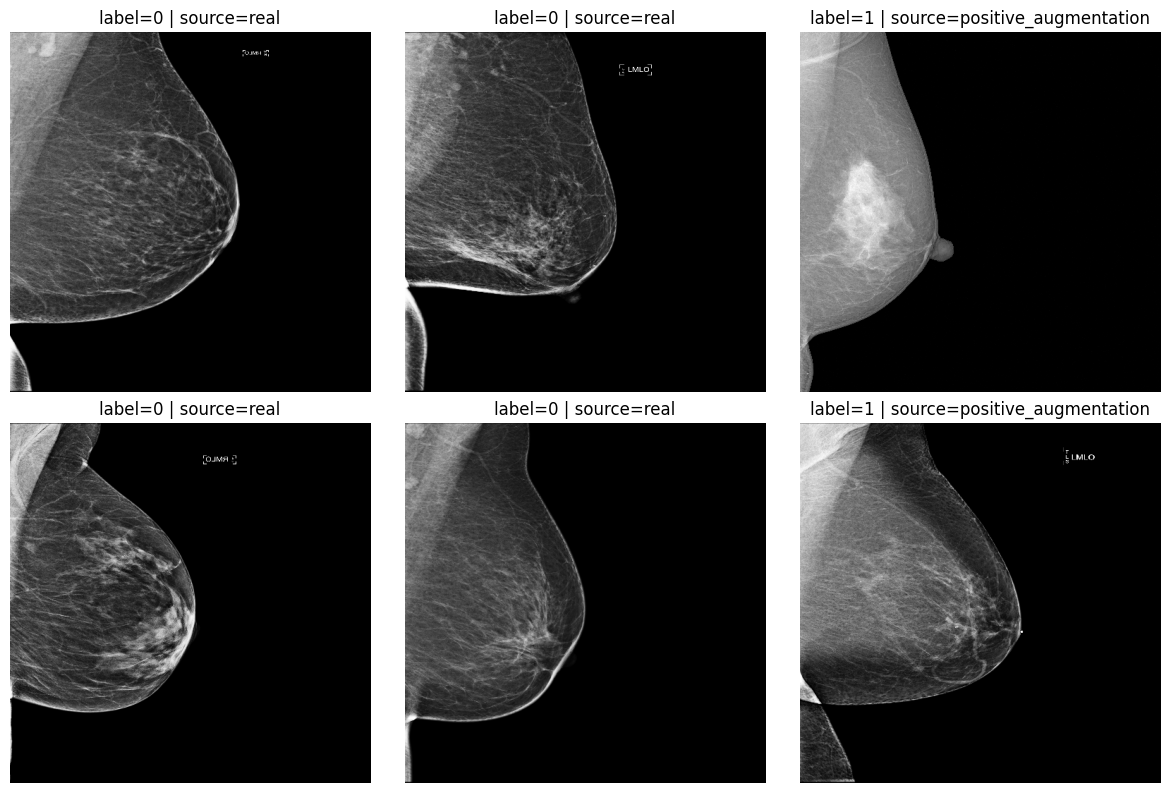

In [5]:
prepare_processed_dataset()
prepare_augmented_dataset()
metadata_df = load_training_metadata()

print("Campioni training:", len(metadata_df))
print("\nDistribuzione label:")
print(metadata_df["label"].value_counts().sort_index())
if "source" in metadata_df.columns:
    print("\nDistribuzione source:")
    print(metadata_df["source"].value_counts())

sample_df = metadata_df.sample(min(6, len(metadata_df)), random_state=42)
fig, axes = plt.subplots(2, 3, figsize=(12, 8))
for axis, (_, row) in zip(axes.flat, sample_df.iterrows()):
    image_path = resolve_training_image_path(row)
    with Image.open(image_path) as image:
        axis.imshow(image.convert("L"), cmap="gray")
    axis.set_title(f'label={row["label"]} | source={row.get("source", "n/a")}')
    axis.axis("off")
for axis in axes.flat[len(sample_df):]:
    axis.axis("off")
plt.tight_layout()
plt.show()

## 3. Modello base e dipendenze

Il modello base viene conservato nella cartella dell'esperimento. Le nuove preparazioni creano alias dei pesi tramite copia fisica; gli artefatti storici già presenti non vengono modificati durante l'apertura del notebook.

In [6]:
MODEL_WEIGHT_ALIASES = {
    "text_encoder": ("model.fp16.safetensors", "model.safetensors"),
    "unet": ("diffusion_pytorch_model.fp16.safetensors", "diffusion_pytorch_model.safetensors"),
    "vae": ("diffusion_pytorch_model.fp16.safetensors", "diffusion_pytorch_model.safetensors"),
}


def has_diffusers_structure(model_dir):
    model_dir = Path(model_dir)
    required = ("model_index.json", "scheduler", "tokenizer", "text_encoder", "vae", "unet")
    return all((model_dir / item).exists() for item in required)


def local_sd_model_ready(model_dir):
    model_dir = Path(model_dir)
    weights = (
        model_dir / "text_encoder" / "model.safetensors",
        model_dir / "unet" / "diffusion_pytorch_model.safetensors",
        model_dir / "vae" / "diffusion_pytorch_model.safetensors",
    )
    return has_diffusers_structure(model_dir) and all(path.is_file() for path in weights)


def create_model_weight_copies(model_dir):
    """Crea sempre copie fisiche con i nomi standard attesi da Diffusers."""
    model_dir = Path(model_dir)
    for subfolder, (source_name, target_name) in MODEL_WEIGHT_ALIASES.items():
        source_path = model_dir / subfolder / source_name
        target_path = model_dir / subfolder / target_name
        if target_path.is_symlink():
            target_path.unlink()
        elif target_path.exists():
            continue
        if not source_path.is_file():
            raise FileNotFoundError(f"Peso sorgente non trovato: {source_path}")
        shutil.copy2(source_path, target_path)


def prepare_pretrained_model():
    if local_sd_model_ready(PRETRAINED_MODEL_DIR) and not FORCE_MODEL_REDOWNLOAD:
        print("Modello Stable Diffusion 2.1 già pronto.")
        return PRETRAINED_MODEL_DIR.resolve()

    download_zip(SD21_MODEL_DRIVE_ID, PRETRAINED_MODEL_ZIP_PATH, FORCE_MODEL_REDOWNLOAD)
    with TemporaryDirectory(prefix="mammo_sd21_extract_") as tmp:
        with zipfile.ZipFile(PRETRAINED_MODEL_ZIP_PATH) as archive:
            archive.extractall(tmp)
        source_dir = find_directory(tmp, has_diffusers_structure, "modello Diffusers")
        if PRETRAINED_MODEL_DIR.exists():
            shutil.rmtree(PRETRAINED_MODEL_DIR)
        shutil.copytree(source_dir, PRETRAINED_MODEL_DIR)
        create_model_weight_copies(PRETRAINED_MODEL_DIR)

    if not local_sd_model_ready(PRETRAINED_MODEL_DIR):
        raise FileNotFoundError("Modello Stable Diffusion 2.1 incompleto dopo l'estrazione.")
    return PRETRAINED_MODEL_DIR.resolve()


LOCAL_MODEL_DIR = prepare_pretrained_model()
print("Modello locale:", LOCAL_MODEL_DIR)

Modello Stable Diffusion 2.1 già pronto.
Modello locale: /mnt/MammoDiffusion/MammoDiffusion/experiments/20260607_sd21_rsna_mlo_512/pretrained_model/stable-diffusion-2-1-base


In [ ]:
# Verifica del repository Diffusers locale e dei riferimenti condivisi
if not TRAIN_SCRIPT.is_file():
    raise FileNotFoundError(f"Script di training non trovato: {TRAIN_SCRIPT}")

SUSTAINABILITY_LOG = EXPERIMENT_DIR / "sustainability_finetuning.jsonl"
print("Diffusers revision:", current_revision)
print("Script training:", TRAIN_SCRIPT)

Diffusers revision: 3759fab56d3170a04d747e918a13e55fda6681e2
Script training: /mnt/MammoDiffusion/MammoDiffusion/experiments/20260607_sd21_rsna_mlo_512/diffusers_repo/examples/text_to_image/train_text_to_image.py


## 4. Fine-tuning

Il dataset viene copiato in uno staging temporaneo compatibile con Diffusers.

Con `RESUME_FROM_CHECKPOINT = "latest"` il training riprende automaticamente dall'ultimo checkpoint disponibile.

In [8]:
def build_training_command(train_data_dir):
    command = [
        sys.executable, "-m", "accelerate.commands.launch",
        "--mixed_precision=fp16",
        "--num_processes=1",
        str(TRAIN_SCRIPT),
        "--pretrained_model_name_or_path", str(LOCAL_MODEL_DIR),
        "--train_data_dir", str(train_data_dir),
        "--image_column", "image",
        "--caption_column", "text",
        "--resolution", str(RESOLUTION),
        "--center_crop",
        "--train_batch_size", str(TRAIN_BATCH_SIZE),
        "--gradient_accumulation_steps", str(GRADIENT_ACCUMULATION_STEPS),
        "--gradient_checkpointing",
        "--max_train_steps", str(MAX_TRAIN_STEPS),
        "--learning_rate", str(LEARNING_RATE),
        "--lr_scheduler", "constant",
        "--lr_warmup_steps", "0",
        "--max_grad_norm", "1",
        "--use_8bit_adam",
        "--checkpointing_steps", str(CHECKPOINTING_STEPS),
        "--checkpoints_total_limit", str(CHECKPOINTS_TOTAL_LIMIT),
        "--validation_prompts", POSITIVE_PROMPT, NEGATIVE_PROMPT,
        "--validation_epochs", "2",
        "--seed", str(TRAIN_SEED),
        "--cache_dir", str(HF_CACHE_DIR),
        "--output_dir", str(SD_OUTPUT_DIR),
        "--report_to", "tensorboard",
        "--logging_dir", str(SD_OUTPUT_DIR / "logs"),
        "--dataloader_num_workers", "0",
    ]
    if RESUME_FROM_CHECKPOINT is not None:
        command.extend(["--resume_from_checkpoint", RESUME_FROM_CHECKPOINT])
    return command


def build_training_environment():
    environment = os.environ.copy()
    environment["PYTORCH_CUDA_ALLOC_CONF"] = "expandable_segments:True"
    conda_prefix = Path(sys.prefix)
    cuda_lib_paths = [
        conda_prefix / "lib",
        conda_prefix / "targets" / "x86_64-linux" / "lib",
        conda_prefix / "lib" / "python3.11" / "site-packages" / "nvidia" / "cu13" / "lib",
        conda_prefix / "lib" / "python3.11" / "site-packages" / "nvidia" / "nvjitlink" / "lib",
    ]
    existing = environment.get("LD_LIBRARY_PATH", "")
    environment["LD_LIBRARY_PATH"] = ":".join(
        [str(path) for path in cuda_lib_paths if path.exists()] + [existing]
    )
    return environment


run_label = f"finetune_sd21_to_{MAX_TRAIN_STEPS}_steps"
if RESUME_FROM_CHECKPOINT is not None:
    run_label += f"_resume_{RESUME_FROM_CHECKPOINT}"
with TemporaryDirectory(prefix="mammo_sd21_train_copy_") as temporary_train_dir:
    temporary_train_dir = Path(temporary_train_dir)
    staged_metadata = stage_training_dataset(metadata_df, temporary_train_dir)
    command = build_training_command(temporary_train_dir)

    print("Staging temporaneo:", temporary_train_dir)
    print("Campioni copiati:", len(staged_metadata))
    print("Comando fine-tuning:\n", " ".join(map(str, command)))

    with measure_sustainability(label=run_label, sample_interval=0.5) as eco:
        process = subprocess.Popen(
            command,
            env=build_training_environment(),
            stdout=subprocess.PIPE,
            stderr=subprocess.STDOUT,
            text=True,
            bufsize=1,
        )
        for line in iter(process.stdout.readline, ""):
            print(line, end="", flush=True)
        process.wait()

record = eco.metrics.to_dict()
record.update({
    "timestamp": datetime.now().isoformat(timespec="seconds"),
    "max_train_steps": MAX_TRAIN_STEPS,
    "resume_from_checkpoint": RESUME_FROM_CHECKPOINT,
    "resolution": RESOLUTION,
    "train_batch_size": TRAIN_BATCH_SIZE,
    "gradient_accumulation_steps": GRADIENT_ACCUMULATION_STEPS,
    "learning_rate": LEARNING_RATE,
    "source_metadata": str(DATA_AUG / "metadata.csv"),
    "staging_strategy": "temporary_copy",
    "output_dir": str(SD_OUTPUT_DIR),
    "returncode": process.returncode,
    "status": "completed" if process.returncode == 0 else "failed",
})
with SUSTAINABILITY_LOG.open("a", encoding="utf-8") as handle:
    handle.write(json.dumps(record, ensure_ascii=False) + "\n")

print("Metriche sostenibilità:", eco.metrics)
print("Staging temporaneo eliminato.")
if process.returncode != 0:
    raise subprocess.CalledProcessError(process.returncode, command)

[codecarbon WARNING @ 11:58:33] Multiple instances of codecarbon are allowed to run at the same time.


Staging temporaneo: /tmp/mammo_sd21_train_copy_7epxivdb
Campioni copiati: 3061
Comando fine-tuning:
 /home/fede/miniforge3/envs/tf-gpu/bin/python -m accelerate.commands.launch --mixed_precision=fp16 --num_processes=1 /mnt/MammoDiffusion/MammoDiffusion/experiments/20260607_sd21_rsna_mlo_512/diffusers_repo/examples/text_to_image/train_text_to_image.py --pretrained_model_name_or_path /mnt/MammoDiffusion/MammoDiffusion/experiments/20260607_sd21_rsna_mlo_512/pretrained_model/stable-diffusion-2-1-base --train_data_dir /tmp/mammo_sd21_train_copy_7epxivdb --image_column image --caption_column text --resolution 512 --center_crop --train_batch_size 2 --gradient_accumulation_steps 4 --gradient_checkpointing --max_train_steps 8000 --learning_rate 1e-05 --lr_scheduler constant --lr_warmup_steps 0 --max_grad_norm 1 --use_8bit_adam --checkpointing_steps 500 --checkpoints_total_limit 32 --validation_prompts grayscale MLO mammogram, breast cancer positive, malignant finding, suspicious lesion, medical 

## 5. Selezione del checkpoint su validation

Per ogni checkpoint si generano campioni delle due classi e si calcolano FID e Inception Score rispetto al validation set. Il test set non viene utilizzato nella scelta del checkpoint.

In [9]:
# Configurazione della selezione checkpoint e della generazione finale
EVAL_DIR = EXPERIMENT_DIR / "eval_checkpoints"
VALIDATION_METADATA_PATH = DATA_PROCESSED_DIR / "metadata" / "val.csv"
TEST_METADATA_PATH = DATA_PROCESSED_DIR / "metadata" / "test.csv"

EVAL_METRICS_PATH = EXPERIMENT_DIR / "checkpoint_validation_metrics.json"
EVAL_SUSTAINABILITY_LOG = EXPERIMENT_DIR / "sustainability_validation.jsonl"

FINAL_GENERATION_LOG = EXPERIMENT_DIR / "sustainability_generation.jsonl"

for _d in [EVAL_DIR, FINAL_GEN_DIR, FINAL_NEG_DIR, FINAL_POS_DIR]:
    _d.mkdir(parents=True, exist_ok=True)

for _metadata_path in [VALIDATION_METADATA_PATH, TEST_METADATA_PATH]:
    if not _metadata_path.exists():
        raise FileNotFoundError(f"Metadata split non trovato: {_metadata_path}")

print(f"Checkpoint sorgente       : {SD_OUTPUT_DIR}")
print(f"Validation metadata       : {VALIDATION_METADATA_PATH}")
print(f"Test metadata             : {TEST_METADATA_PATH}")
print(f"Immagini generate/ckpt/cls: {N_EVAL_IMAGES_PER_CLASS}")
print(f"Immagini validation/classe: {N_VALIDATION_IMAGES_PER_CLASS}")
print(f"Immagini test/classe      : {N_TEST_IMAGES_PER_CLASS}")
print(f"Immagini finali/classe    : {N_FINAL_IMAGES_PER_CLASS}")

Checkpoint sorgente       : /mnt/MammoDiffusion/MammoDiffusion/experiments/20260607_sd21_rsna_mlo_512/model
Validation metadata       : /mnt/MammoDiffusion/MammoDiffusion/data/processed/metadata/val.csv
Test metadata             : /mnt/MammoDiffusion/MammoDiffusion/data/processed/metadata/test.csv
Immagini generate/ckpt/cls: 100
Immagini validation/classe: 73
Immagini test/classe      : 73
Immagini finali/classe    : 1361


In [10]:
# Riferimenti reali temporanei per validation/test, sempre tramite copia
def resolve_split_image_path(raw_path, split_name, label):
    original = Path(str(raw_path)).expanduser()
    candidates = [original] if original.is_absolute() else [PROJECT_ROOT / original]
    if "data" in original.parts:
        candidates.append(PROJECT_ROOT / Path(*original.parts[original.parts.index("data"):]))
    candidates.append(DATA_PROCESSED_DIR / split_name / str(int(label)) / original.name)

    for candidate in dict.fromkeys(candidates):
        if candidate.is_file():
            return candidate.resolve()
    checked = "\n".join(f"  - {candidate}" for candidate in dict.fromkeys(candidates))
    raise FileNotFoundError(f"Immagine non trovata per {raw_path}. Percorsi controllati:\n{checked}")


def get_real_image_paths_from_split_metadata(metadata_path, label, n_images, seed=42):
    metadata_path = Path(metadata_path)
    metadata = pd.read_csv(metadata_path)
    required = {"label", "processed_path"}
    missing = required.difference(metadata.columns)
    if missing:
        raise ValueError(f"Colonne mancanti in {metadata_path}: {sorted(missing)}")

    subset = metadata[metadata["label"].astype(int) == int(label)]
    if subset.empty:
        raise ValueError(f"Nessuna immagine label={label} in {metadata_path}")
    n_take = len(subset) if n_images is None else min(int(n_images), len(subset))
    if n_images is not None and n_take < n_images:
        print(f"Richieste {n_images} immagini label={label}; disponibili {n_take}.")

    subset = subset.sample(n=n_take, random_state=seed)
    return [
        resolve_split_image_path(raw_path, metadata_path.stem.lower(), label)
        for raw_path in subset["processed_path"]
    ]


@contextmanager
def temporary_real_reference_dir_from_split_metadata(metadata_path, label, n_images, seed=42):
    image_paths = get_real_image_paths_from_split_metadata(metadata_path, label, n_images, seed)
    with TemporaryDirectory(prefix=f"real_ref_label{label}_") as tmp:
        tmp_dir = Path(tmp)
        for index, source_path in enumerate(image_paths):
            destination = tmp_dir / f"real_{label}_{index:04d}{source_path.suffix.lower()}"
            shutil.copy2(source_path, destination)
        yield tmp_dir


@contextmanager
def temporary_real_reference_dirs_from_split_metadata(metadata_path, n_per_class, seed=42):
    with temporary_real_reference_dir_from_split_metadata(
        metadata_path, label=0, n_images=n_per_class, seed=seed
    ) as real_neg_dir, temporary_real_reference_dir_from_split_metadata(
        metadata_path, label=1, n_images=n_per_class, seed=seed + 1
    ) as real_pos_dir:
        yield real_neg_dir, real_pos_dir


print("Selezione checkpoint: validation.")
print("Valutazione finale: test, esclusivamente nell'ultima cella.")

Selezione checkpoint: validation.
Valutazione finale: test, esclusivamente nell'ultima cella.


In [11]:
# Utility per checkpoint, generazione e metriche
def discover_checkpoints(output_dir):
    checkpoints = []
    for path in Path(output_dir).glob("checkpoint-*"):
        match = re.fullmatch(r"checkpoint-(\d+)", path.name)
        if match and path.is_dir() and (path / "unet").is_dir():
            checkpoints.append((int(match.group(1)), path))
    return sorted(checkpoints)


def load_pipeline_from_checkpoint(checkpoint_path, base_model_dir, device="cuda"):
    unet = UNet2DConditionModel.from_pretrained(
        str(Path(checkpoint_path) / "unet"),
        torch_dtype=torch.float16,
    )
    pipeline = StableDiffusionPipeline.from_pretrained(
        str(base_model_dir),
        unet=unet,
        torch_dtype=torch.float16,
        safety_checker=None,
        requires_safety_checker=False,
    ).to(device)
    pipeline.set_progress_bar_config(disable=True)
    return pipeline


def count_pngs(directory):
    return len(list(Path(directory).glob("*.png"))) if Path(directory).exists() else 0


def generate_images_to_dir(
    pipeline, prompt, out_dir, n, inference_steps, guidance_scale, seed, resolution=512
):
    out_dir = Path(out_dir)
    out_dir.mkdir(parents=True, exist_ok=True)
    n_existing = count_pngs(out_dir)
    if n_existing >= n:
        print(f"    {n_existing} immagini già presenti, skip")
        return

    print(f"    {n_existing} già presenti, genero {n - n_existing} mancanti")
    generator = torch.Generator("cuda").manual_seed(seed + n_existing)
    for index in tqdm(range(n_existing, n), desc=f"  Generazione {out_dir.name}", unit="img"):
        image = pipeline(
            prompt,
            num_inference_steps=inference_steps,
            guidance_scale=guidance_scale,
            height=resolution,
            width=resolution,
            generator=generator,
        ).images[0]
        image.save(out_dir / f"gen_{index:04d}.png")


def eval_one_checkpoint(
    step,
    ckpt_path,
    base_model_dir,
    real_neg_dir,
    real_pos_dir,
    eval_dir,
    n_gen,
    inference_steps,
    guidance_scale,
    seed,
    resolution=512,
):
    class_config = {
        "negative": (NEGATIVE_PROMPT, Path(real_neg_dir), seed),
        "positive": (POSITIVE_PROMPT, Path(real_pos_dir), seed + 1),
    }
    generated_dirs = {
        name: Path(eval_dir) / f"checkpoint-{step}" / name
        for name in class_config
    }

    print(f"\nCheckpoint {step} | {Path(ckpt_path).name}")
    needs_generation = any(count_pngs(path) < n_gen for path in generated_dirs.values())
    pipeline = load_pipeline_from_checkpoint(ckpt_path, base_model_dir) if needs_generation else None
    try:
        for name, (prompt, _, class_seed) in class_config.items():
            if count_pngs(generated_dirs[name]) < n_gen:
                print(f"  Generazione {name}...")
                generate_images_to_dir(
                    pipeline,
                    prompt,
                    generated_dirs[name],
                    n_gen,
                    inference_steps,
                    guidance_scale,
                    class_seed,
                    resolution,
                )
    finally:
        if pipeline is not None:
            del pipeline
            gc.collect()
            torch.cuda.empty_cache()

    metrics = {}
    for name, (_, real_dir, _) in class_config.items():
        print(f"  FID + IS: {name}")
        metrics[name] = GenerativeEvaluator(
            real_dir=real_dir,
            generated_dir=generated_dirs[name],
            batch_size=8,
            num_workers=0,
        ).compute()

    averages = {
        metric: round(sum(metrics[name][metric] for name in metrics) / len(metrics), 4)
        for metric in ("FID", "IS_mean", "IS_std")
    }
    print(f"  Avg FID={averages['FID']:.4f} | IS={averages['IS_mean']:.4f}±{averages['IS_std']:.4f}")
    return {
        "step": step,
        "ckpt_name": Path(ckpt_path).name,
        **metrics,
        "avg_FID": averages["FID"],
        "avg_IS_mean": averages["IS_mean"],
        "avg_IS_std": averages["IS_std"],
    }


def copy_eval_images_to_final(eval_src_dir, final_dst_dir, max_images, prefix):
    final_dst_dir = Path(final_dst_dir)
    final_dst_dir.mkdir(parents=True, exist_ok=True)
    eval_images = sorted(Path(eval_src_dir).glob("*.png"))[:max_images]
    for index, source_path in enumerate(eval_images):
        shutil.copy2(source_path, final_dst_dir / f"{prefix}_{index:04d}.png")
    print(f"  Riutilizzate {len(eval_images)} immagini da {Path(eval_src_dir).name}.")
    return len(eval_images)


def file_sha256(path):
    digest = hashlib.sha256()
    with Path(path).open("rb") as handle:
        for block in iter(lambda: handle.read(1024 * 1024), b""):
            digest.update(block)
    return digest.hexdigest()


def remove_generated_duplicates_of_reused_images(final_dir, reused_prefix):
    final_dir = Path(final_dir)
    reused_hashes = {file_sha256(path) for path in final_dir.glob(f"{reused_prefix}_*.png")}
    removed = []
    for path in sorted(final_dir.glob("gen_*.png")):
        if file_sha256(path) in reused_hashes:
            path.unlink()
            removed.append(path)
    if removed:
        print(f"  Rimosse {len(removed)} copie gen_* sovrapposte alle immagini riusate.")
    return removed


def duplicate_png_groups(directory):
    by_hash = {}
    for path in sorted(Path(directory).glob("*.png")):
        by_hash.setdefault(file_sha256(path), []).append(path.name)
    return {digest: names for digest, names in by_hash.items() if len(names) > 1}


def file_signature(path):
    path = Path(path)
    return {
        "path": str(path),
        "size": path.stat().st_size,
        "mtime_ns": path.stat().st_mtime_ns,
    }


def png_files_signature(directory):
    return [
        {
            "name": path.name,
            "size": path.stat().st_size,
            "mtime_ns": path.stat().st_mtime_ns,
        }
        for path in sorted(Path(directory).glob("*.png"))
    ]

In [12]:
# Valutazione di tutti i checkpoint usando esclusivamente il validation
checkpoints = discover_checkpoints(SD_OUTPUT_DIR)
print(f"Trovati {len(checkpoints)} checkpoint:")
for _step, _p in checkpoints:
    print(f"  checkpoint-{_step}")

CHECKPOINT_EVAL_CACHE_PATH = EXPERIMENT_DIR / "checkpoint_validation_cache.json"
FORCE_RECOMPUTE_CHECKPOINT_EVAL = False

checkpoint_eval_config = {
    "metric_backend": "generative_evaluator_finetuning.py",
    "reference_split": "validation",
    "n_per_class": N_VALIDATION_IMAGES_PER_CLASS,
    "eval_seed": EVAL_SEED,
    "inference_steps": EVAL_INFERENCE_STEPS,
    "guidance_scale": EVAL_GUIDANCE_SCALE,
    "resolution": RESOLUTION,
    "n_gen_per_class": N_EVAL_IMAGES_PER_CLASS,
}
validation_csv_signature = file_signature(VALIDATION_METADATA_PATH)

cached_checkpoints = {}
if CHECKPOINT_EVAL_CACHE_PATH.exists() and not FORCE_RECOMPUTE_CHECKPOINT_EVAL:
    try:
        with open(CHECKPOINT_EVAL_CACHE_PATH, encoding="utf-8") as f:
            _cache_payload = json.load(f)
        if (
            _cache_payload.get("schema_version") == 1
            and _cache_payload.get("config") == checkpoint_eval_config
            and _cache_payload.get("validation_csv") == validation_csv_signature
        ):
            cached_checkpoints = _cache_payload.get("checkpoints", {})
    except Exception as exc:
        print(f"Cache checkpoint non leggibile, ricalcolo da zero: {exc}")

all_metrics = []
recomputed_any = False
with temporary_real_reference_dirs_from_split_metadata(
    metadata_path=VALIDATION_METADATA_PATH,
    n_per_class=N_VALIDATION_IMAGES_PER_CLASS,
    seed=EVAL_SEED,
) as (real_neg_ref_dir, real_pos_ref_dir):
    print("\nDirectory temporanee validation:")
    print("  Negative:", real_neg_ref_dir)
    print("  Positive:", real_pos_ref_dir)

    with measure_sustainability(label="checkpoint_validation_evaluation", sample_interval=0.5) as eco_eval:
        for step, ckpt_path in checkpoints:
            ckpt_name = ckpt_path.name
            neg_dir = EVAL_DIR / ckpt_name / "negative"
            pos_dir = EVAL_DIR / ckpt_name / "positive"
            current_signature = {
                "negative": png_files_signature(neg_dir),
                "positive": png_files_signature(pos_dir),
            }
            cached_entry = cached_checkpoints.get(ckpt_name)
            if (
                cached_entry is not None
                and cached_entry.get("input_signature") == current_signature
                and count_pngs(neg_dir) == N_EVAL_IMAGES_PER_CLASS
                and count_pngs(pos_dir) == N_EVAL_IMAGES_PER_CLASS
            ):
                print(f"\nCheckpoint {step} | {ckpt_name}: metriche da cache, skip")
                all_metrics.append(cached_entry["metrics"])
                continue

            recomputed_any = True
            metrics_entry = eval_one_checkpoint(
                step=step,
                ckpt_path=ckpt_path,
                base_model_dir=LOCAL_MODEL_DIR,
                real_neg_dir=real_neg_ref_dir,
                real_pos_dir=real_pos_ref_dir,
                eval_dir=EVAL_DIR,
                n_gen=N_EVAL_IMAGES_PER_CLASS,
                inference_steps=EVAL_INFERENCE_STEPS,
                guidance_scale=EVAL_GUIDANCE_SCALE,
                seed=EVAL_SEED,
                resolution=RESOLUTION,
            )
            all_metrics.append(metrics_entry)
            cached_checkpoints[ckpt_name] = {
                "input_signature": {
                    "negative": png_files_signature(neg_dir),
                    "positive": png_files_signature(pos_dir),
                },
                "metrics": metrics_entry,
            }

with open(EVAL_METRICS_PATH, "w", encoding="utf-8") as f:
    json.dump(all_metrics, f, indent=2, ensure_ascii=False)

with open(CHECKPOINT_EVAL_CACHE_PATH, "w", encoding="utf-8") as f:
    json.dump({
        "schema_version": 1,
        "config": checkpoint_eval_config,
        "validation_csv": validation_csv_signature,
        "checkpoints": cached_checkpoints,
    }, f, indent=2, ensure_ascii=False)

if recomputed_any:
    _eco_record = eco_eval.metrics.to_dict()
    _eco_record.update({
        "timestamp": datetime.now().isoformat(timespec="seconds"),
        "record_type": "checkpoint_validation_evaluation",
        "n_checkpoints": len(checkpoints),
        "n_real_images_per_class": N_VALIDATION_IMAGES_PER_CLASS,
        "n_generated_images_per_class": N_EVAL_IMAGES_PER_CLASS,
        "real_reference_metadata": str(VALIDATION_METADATA_PATH),
    })
    with open(EVAL_SUSTAINABILITY_LOG, "a", encoding="utf-8") as f:
        f.write(json.dumps(_eco_record, ensure_ascii=False) + "\n")
    print(f"\nMetriche eco-tracking validation:\n{eco_eval.metrics}")
else:
    print("\nTutte le metriche caricate da cache, nessun checkpoint ricalcolato.")

print(f"Metriche validation salvate in: {EVAL_METRICS_PATH}")

Trovati 16 checkpoint:
  checkpoint-500
  checkpoint-1000
  checkpoint-1500
  checkpoint-2000
  checkpoint-2500
  checkpoint-3000
  checkpoint-3500
  checkpoint-4000
  checkpoint-4500
  checkpoint-5000
  checkpoint-5500
  checkpoint-6000
  checkpoint-6500
  checkpoint-7000
  checkpoint-7500
  checkpoint-8000

Directory temporanee validation:
  Negative: /tmp/real_ref_label0_n1pf211v
  Positive: /tmp/real_ref_label1_k56_3z5a

Checkpoint 500 | checkpoint-500: metriche da cache, skip

Checkpoint 1000 | checkpoint-1000: metriche da cache, skip

Checkpoint 1500 | checkpoint-1500: metriche da cache, skip

Checkpoint 2000 | checkpoint-2000: metriche da cache, skip

Checkpoint 2500 | checkpoint-2500: metriche da cache, skip

Checkpoint 3000 | checkpoint-3000: metriche da cache, skip

Checkpoint 3500 | checkpoint-3500: metriche da cache, skip

Checkpoint 4000 | checkpoint-4000: metriche da cache, skip

Checkpoint 4500 | checkpoint-4500: metriche da cache, skip

Checkpoint 5000 | checkpoint-5000

In [13]:
# Selezione best checkpoint
# Ricarica da file (idempotente se si ri-esegue la cella)
with open(EVAL_METRICS_PATH, encoding="utf-8") as f:
    all_metrics = json.load(f)

df_eval = pd.DataFrame([
    {
        "checkpoint":  m["ckpt_name"],
        "step":        m["step"],
        "avg_FID":     m["avg_FID"],
        "avg_IS_mean": m["avg_IS_mean"],
        "avg_IS_std":  m["avg_IS_std"],
        "FID_neg":     m["negative"]["FID"],
        "FID_pos":     m["positive"]["FID"],
        "IS_neg":      m["negative"]["IS_mean"],
        "IS_pos":      m["positive"]["IS_mean"],
    }
    for m in all_metrics
]).sort_values("avg_FID").reset_index(drop=True)

print("Riepilogo metriche (ordinato per avg_FID crescente — migliore prima):")
print(df_eval.to_string(index=False))

best_row        = df_eval.iloc[0]
BEST_CHECKPOINT = SD_OUTPUT_DIR / best_row["checkpoint"]

print(f"\n✓ Miglior checkpoint : {best_row['checkpoint']}")
print(f"  avg FID  : {best_row['avg_FID']:.4f}")
print(f"  avg IS   : {best_row['avg_IS_mean']:.4f} ± {best_row['avg_IS_std']:.4f}")
print(f"  Path     : {BEST_CHECKPOINT}")

Riepilogo metriche (ordinato per avg_FID crescente — migliore prima):
     checkpoint  step  avg_FID  avg_IS_mean  avg_IS_std  FID_neg  FID_pos  IS_neg  IS_pos
checkpoint-3000  3000 129.6345       2.3537      0.2879 137.0138 122.2551  2.3691  2.3382
checkpoint-2500  2500 138.4129       2.1883      0.3414 137.7336 139.0923  2.1306  2.2459
checkpoint-4000  4000 140.2011       2.1718      0.2626 150.0427 130.3595  2.2268  2.1168
checkpoint-5000  5000 142.7443       2.3293      0.2102 159.8514 125.6371  2.3914  2.2672
checkpoint-3500  3500 145.4554       2.0516      0.2220 152.1957 138.7151  2.1159  1.9873
checkpoint-6500  6500 159.6256       2.1393      0.2247 183.0833 136.1678  2.1392  2.1393
checkpoint-1000  1000 163.5288       2.0586      0.3266 163.9823 163.0752  2.0190  2.0982
checkpoint-1500  1500 164.0655       2.0320      0.1435 167.4250 160.7060  2.0116  2.0525
checkpoint-5500  5500 164.2925       2.2411      0.1879 181.6260 146.9590  2.2493  2.2329
checkpoint-8000  8000 168.9787

## 6. Generazione finale

Il checkpoint con FID medio migliore sul validation produce il dataset
sintetico finale. Le immagini già presenti vengono riutilizzate e la
generazione completa soltanto gli eventuali file mancanti.

In [ ]:
# Generazione finale con il miglior checkpoint
print(f"Best checkpoint  : {BEST_CHECKPOINT.name}")
print(f"Immagini/classe  : {N_FINAL_IMAGES_PER_CLASS}")
print(f"Output           : {FINAL_GEN_DIR}")

BEST_EVAL_DIR = EVAL_DIR / BEST_CHECKPOINT.name
_class_config = {
    "negative": {
        "prompt": NEGATIVE_PROMPT,
        "final_dir": FINAL_NEG_DIR,
        "eval_dir": BEST_EVAL_DIR / "negative",
        "seed": EVAL_SEED,
        "prefix": "eval_neg",
    },
    "positive": {
        "prompt": POSITIVE_PROMPT,
        "final_dir": FINAL_POS_DIR,
        "eval_dir": BEST_EVAL_DIR / "positive",
        "seed": EVAL_SEED + 1,
        "prefix": "eval_pos",
    },
}

_final_already_complete = all(
    count_pngs(_class_config[_cls]["final_dir"]) == N_FINAL_IMAGES_PER_CLASS
    for _cls in FINAL_GENERATE_CLASSES
)
if _final_already_complete:
    print("Dataset finale già completo: la generazione verrà saltata.")
generation_info_path = EXPERIMENT_DIR / "generation_info.json"
if generation_info_path.exists():
    with open(generation_info_path, encoding="utf-8") as f:
        previous_generation = json.load(f)
    previous_best = previous_generation.get("best_checkpoint")
    final_images_exist = any(count_pngs(cfg["final_dir"]) > 0 for cfg in _class_config.values())
    if previous_best and previous_best != BEST_CHECKPOINT.name and final_images_exist:
        raise RuntimeError(
            f"Il best checkpoint e' cambiato da {previous_best} a {BEST_CHECKPOINT.name}. "
            "Usa una nuova FINAL_GEN_DIR o svuota consapevolmente le cartelle finali."
        )

pipe_final = None if _final_already_complete else load_pipeline_from_checkpoint(BEST_CHECKPOINT, LOCAL_MODEL_DIR)
removed_overlaps = {}

with measure_sustainability(label=f"final_gen_{BEST_CHECKPOINT.name}", sample_interval=0.5) as eco_final:
    for _cls in FINAL_GENERATE_CLASSES:
        cfg = _class_config[_cls]
        if count_pngs(cfg["final_dir"]) == N_FINAL_IMAGES_PER_CLASS:
            print(f"Classe {_cls.upper()}: {N_FINAL_IMAGES_PER_CLASS} immagini già presenti, skip")
            continue
        eval_available = min(count_pngs(cfg["eval_dir"]), N_EVAL_IMAGES_PER_CLASS)

        print(f"\nClasse {_cls.upper()}")
        print(f"  Target finale              : {N_FINAL_IMAGES_PER_CLASS}")
        print(f"  Immagini eval riutilizzate : {eval_available}")

        # Copia prima le immagini riusate, poi completa il totale
        copy_eval_images_to_final(
            eval_src_dir=cfg["eval_dir"],
            final_dst_dir=cfg["final_dir"],
            max_images=eval_available,
            prefix=cfg["prefix"],
        )
        removed = remove_generated_duplicates_of_reused_images(
            final_dir=cfg["final_dir"],
            reused_prefix=cfg["prefix"],
        )
        removed_overlaps[_cls] = len(removed)

        n_before = count_pngs(cfg["final_dir"])
        print(f"  Immagini uniche presenti   : {n_before}")
        print(f"  Nuove da generare          : {max(0, N_FINAL_IMAGES_PER_CLASS - n_before)}")

        generate_images_to_dir(
            pipe_final,
            cfg["prompt"],
            cfg["final_dir"],
            N_FINAL_IMAGES_PER_CLASS,
            EVAL_INFERENCE_STEPS,
            EVAL_GUIDANCE_SCALE,
            cfg["seed"],
            RESOLUTION,
        )

        duplicates = duplicate_png_groups(cfg["final_dir"])
        if duplicates:
            raise RuntimeError(f"Trovati {len(duplicates)} gruppi duplicati in {cfg['final_dir']}.")
        if count_pngs(cfg["final_dir"]) != N_FINAL_IMAGES_PER_CLASS:
            raise RuntimeError(f"Numero finale non valido per {_cls}.")

del pipe_final
gc.collect()
torch.cuda.empty_cache()

_n_neg = count_pngs(FINAL_NEG_DIR)
_n_pos = count_pngs(FINAL_POS_DIR)
_final_record = eco_final.metrics.to_dict()
_final_record.update({
    "timestamp": datetime.now().isoformat(timespec="seconds"),
    "record_type": "final_generation",
    "generation_log_schema": 2,
    "best_checkpoint": BEST_CHECKPOINT.name,
    "selection_reference": "validation",
    "selection_metrics_path": str(EVAL_METRICS_PATH),
    "avg_FID": float(best_row["avg_FID"]),
    "avg_IS_mean": float(best_row["avg_IS_mean"]),
    "n_per_class": N_FINAL_IMAGES_PER_CLASS,
    "n_eval_reused": N_EVAL_IMAGES_PER_CLASS,
    "removed_overlaps": removed_overlaps,
    "n_negative_final": _n_neg,
    "n_positive_final": _n_pos,
    "inference_steps": EVAL_INFERENCE_STEPS,
    "guidance_scale": EVAL_GUIDANCE_SCALE,
    "generated_classes": FINAL_GENERATE_CLASSES,
    "generated_negative": str(FINAL_NEG_DIR),
    "generated_positive": str(FINAL_POS_DIR),
    "status": "completed",
})

with open(generation_info_path, "w", encoding="utf-8") as f:
    json.dump(_final_record, f, indent=2, ensure_ascii=False)
with open(FINAL_GENERATION_LOG, "a", encoding="utf-8") as f:
    f.write(json.dumps(_final_record, ensure_ascii=False) + "\n")

print(f"\nMetriche eco-tracking generazione finale:\n{eco_final.metrics}")
print(f"Positive finali: {_n_pos} -> {FINAL_POS_DIR}")

Best checkpoint  : checkpoint-3000
Immagini/classe  : 1361
Output           : /mnt/MammoDiffusion/MammoDiffusion/experiments/20260607_sd21_rsna_mlo_512/generated_images/final
Dataset finale già completo: la generazione verrà saltata.
Classe POSITIVE: 1361 immagini già presenti, skip
Classe NEGATIVE: 1361 immagini già presenti, skip

Metriche eco-tracking generazione finale:
[final_gen_checkpoint-3000] Tempo: 0.00s | RAM picco: 1174.5 MB | Energia: 0.000026 kWh | CO2: 0.000006 kg | Sample: 0.500s
Positive finali: 1361 -> /mnt/MammoDiffusion/MammoDiffusion/experiments/20260607_sd21_rsna_mlo_512/generated_images/final/positive


## 7. Test finale

Per ogni classe generata si calcolano FID e Inception Score rispetto alle immagini reali del test set. I file riepilogativi vengono aggiornati a ogni riesecuzione della cella.

In [15]:
# TEST FINALE: tutte le sintetiche contro i reali del test
FINAL_TEST_METRICS_PATH = EXPERIMENT_DIR / "final_test_metrics.json"
FINAL_TEST_METRICS_CSV = EXPERIMENT_DIR / "final_test_metrics.csv"
FORCE_RECOMPUTE_FINAL_TEST = False

_final_test_config = {
    "negative": {"label": 0, "gen_dir": FINAL_NEG_DIR},
    "positive": {"label": 1, "gen_dir": FINAL_POS_DIR},
}

final_eval_config = {
    "metric_backend": "generative_evaluator_finetuning.py",
    "reference_split": "test",
    "n_test_per_class": N_TEST_IMAGES_PER_CLASS,
    "classes": FINAL_GENERATE_CLASSES,
    "generated_dirs": {
        cls: str(_final_test_config[cls]["gen_dir"]) for cls in FINAL_GENERATE_CLASSES
    },
}
final_input_signature = {
    "classes": {
        cls: png_files_signature(_final_test_config[cls]["gen_dir"])
        for cls in FINAL_GENERATE_CLASSES
    },
    "test_csv": file_signature(TEST_METADATA_PATH),
}

use_final_cache = False
if FINAL_TEST_METRICS_PATH.exists() and not FORCE_RECOMPUTE_FINAL_TEST:
    try:
        with open(FINAL_TEST_METRICS_PATH, encoding="utf-8") as f:
            final_test_summary = json.load(f)
        use_final_cache = (
            final_test_summary.get("schema_version") == 2
            and final_test_summary.get("config") == final_eval_config
            and final_test_summary.get("input_signature") == final_input_signature
            and FINAL_TEST_METRICS_CSV.exists()
        )
    except Exception as exc:
        print(f"Cache test finale non leggibile, ricalcolo: {exc}")

if use_final_cache:
    df_final_test = pd.read_csv(FINAL_TEST_METRICS_CSV)
    final_test_metrics = final_test_summary.get("per_class", {})
    print("TEST FINALE: metriche caricate da cache.")
    print("Checkpoint scelto sul validation:", BEST_CHECKPOINT.name)
    print("Salvate in:", FINAL_TEST_METRICS_PATH)
else:
    final_test_metrics = {}

    print("TEST FINALE immagini generate con FID + Inception Score")
    print("Checkpoint scelto sul validation:", BEST_CHECKPOINT.name)
    print("Metadata test:", TEST_METADATA_PATH)

    for _cls in FINAL_GENERATE_CLASSES:
        label = _final_test_config[_cls]["label"]
        gen_dir = _final_test_config[_cls]["gen_dir"]
        n_generated = count_pngs(gen_dir)

        if n_generated != N_FINAL_IMAGES_PER_CLASS:
            raise RuntimeError(
                f"Dataset sintetico incompleto per {_cls}: {n_generated} != {N_FINAL_IMAGES_PER_CLASS}."
            )
        duplicates = duplicate_png_groups(gen_dir)
        if duplicates:
            raise RuntimeError(f"Il dataset sintetico contiene {len(duplicates)} gruppi duplicati.")

        print(f"\nClasse {_cls.upper()}: {n_generated} generate vs {N_TEST_IMAGES_PER_CLASS} reali test")
        with temporary_real_reference_dir_from_split_metadata(
            metadata_path=TEST_METADATA_PATH,
            label=label,
            n_images=N_TEST_IMAGES_PER_CLASS,
            seed=EVAL_SEED + label,
        ) as real_test_dir:
            metrics = GenerativeEvaluator(
                real_dir=real_test_dir,
                generated_dir=gen_dir,
                batch_size=8,
                num_workers=0,
            ).compute()

        final_test_metrics[_cls] = {
            "FID": metrics["FID"],
            "IS_mean": metrics["IS_mean"],
            "IS_std": metrics["IS_std"],
            "n_generated": n_generated,
            "real_reference_metadata": str(TEST_METADATA_PATH),
            "real_label": label,
            "n_real_reference": N_TEST_IMAGES_PER_CLASS,
            "generated_dir": str(gen_dir),
        }

    avg_fid = round(sum(m["FID"] for m in final_test_metrics.values()) / len(final_test_metrics), 4)
    avg_is_mean = round(sum(m["IS_mean"] for m in final_test_metrics.values()) / len(final_test_metrics), 4)
    avg_is_std = round(sum(m["IS_std"] for m in final_test_metrics.values()) / len(final_test_metrics), 4)

    final_test_summary = {
        "schema_version": 2,
        "config": final_eval_config,
        "input_signature": final_input_signature,
        "best_checkpoint": BEST_CHECKPOINT.name,
        "checkpoint_selection_reference": "validation",
        "checkpoint_selection_metrics": str(EVAL_METRICS_PATH),
        "final_evaluation_reference": "test",
        "classes_evaluated": list(final_test_metrics),
        "avg_FID": avg_fid,
        "avg_IS_mean": avg_is_mean,
        "avg_IS_std": avg_is_std,
        "real_reference_metadata": str(TEST_METADATA_PATH),
        "n_real_reference_per_class": N_TEST_IMAGES_PER_CLASS,
        "per_class": final_test_metrics,
        "timestamp": datetime.now().isoformat(timespec="seconds"),
    }

    with open(FINAL_TEST_METRICS_PATH, "w", encoding="utf-8") as f:
        json.dump(final_test_summary, f, indent=2, ensure_ascii=False)

    df_final_test = pd.DataFrame([
        {
            "class": cls,
            "FID": m["FID"],
            "IS_mean": m["IS_mean"],
            "IS_std": m["IS_std"],
            "n_generated": m["n_generated"],
            "real_reference_metadata": m["real_reference_metadata"],
            "real_label": m["real_label"],
            "n_real_reference": m["n_real_reference"],
            "generated_dir": m["generated_dir"],
        }
        for cls, m in final_test_metrics.items()
    ])
    df_final_test.loc[len(df_final_test)] = {
        "class": "average",
        "FID": avg_fid,
        "IS_mean": avg_is_mean,
        "IS_std": avg_is_std,
        "n_generated": df_final_test["n_generated"].sum(),
        "real_reference_metadata": str(TEST_METADATA_PATH),
        "real_label": "",
        "n_real_reference": N_TEST_IMAGES_PER_CLASS,
        "generated_dir": "",
    }
    df_final_test.to_csv(FINAL_TEST_METRICS_CSV, index=False)

print("\nMetriche finali sul test:")
print(df_final_test.to_string(index=False))
print("\nSalvate in:", FINAL_TEST_METRICS_PATH, "e", FINAL_TEST_METRICS_CSV)

TEST FINALE: metriche caricate da cache.
Checkpoint scelto sul validation: checkpoint-3000
Salvate in: /mnt/MammoDiffusion/MammoDiffusion/experiments/20260607_sd21_rsna_mlo_512/final_test_metrics.json

Metriche finali sul test:
   class      FID  IS_mean  IS_std  n_generated                                             real_reference_metadata  real_label  n_real_reference                                                                                             generated_dir
positive 118.9844   2.7105  0.1203         1361 /mnt/MammoDiffusion/MammoDiffusion/data/processed/metadata/test.csv         1.0                73 /mnt/MammoDiffusion/MammoDiffusion/experiments/20260607_sd21_rsna_mlo_512/generated_images/final/positive
negative 123.9415   2.7935  0.2040         1361 /mnt/MammoDiffusion/MammoDiffusion/data/processed/metadata/test.csv         0.0                73 /mnt/MammoDiffusion/MammoDiffusion/experiments/20260607_sd21_rsna_mlo_512/generated_images/final/negative
 average 121.463